# **Comparison library between CHASM and BI-RME simulations**

In [117]:
import os, scipy
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import find_peaks

benchmark_no = 4

results_dir = os.path.join("results", f"benchmark_{benchmark_no}")
os.makedirs(results_dir, exist_ok=True)

## Import files

In [118]:
file_path_BIRME = os.path.join("BIRME", f"I-V_bench{benchmark_no}_th45.mat")
freq_file = os.path.join("BIRME","frequencies.mat")
file_path_CHASM = os.path.join("CHASM", f"ben_{benchmark_no}_output.npy")


data_BIRME_1 = scipy.io.loadmat(file_path_BIRME)
data_BIRME_2 = scipy.io.loadmat(freq_file)
data_CHASM = np.load(file_path_CHASM, allow_pickle=True).item()

In [119]:
V_c_BIRME = data_BIRME_1["V_GW"].flatten()
freqs_BIRME = data_BIRME_2["freq_total"].flatten()

V_meas_CHASM = data_CHASM["V_meas"]
freqs_CHASM = data_CHASM["freqs"]

I_gw_BIRME = data_BIRME_1["I_GW"].flatten()
I_gw_CHASM = data_CHASM["I_gw"]

### Convert CHASM result to cavity voltage

In [120]:
a = 2.11e-3
b = 0.635e-3

V_c_CHASM = V_meas_CHASM / np.sqrt(np.log(a/b)/(2*np.pi))

## Plot cavity voltage data

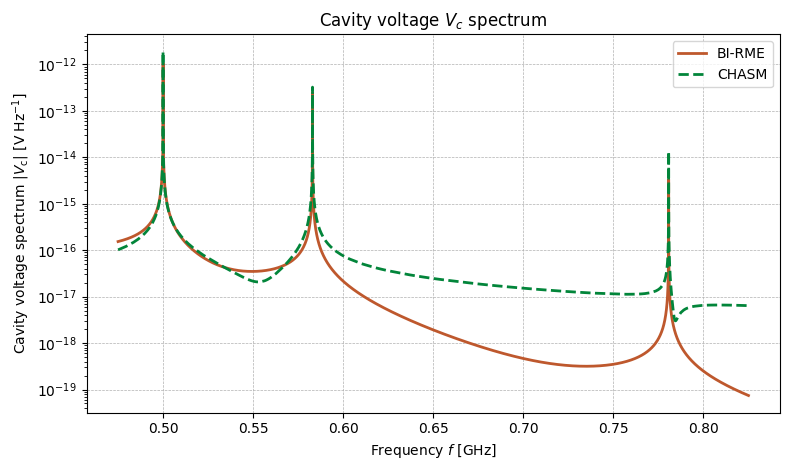

In [121]:
plt.figure(figsize=(8, 4.8))

plt.plot(
    freqs_BIRME / 1e9,
    np.abs(V_c_BIRME),
    color="#be582d",
    linewidth=2,
    label="BI-RME",
)

plt.plot(
    freqs_CHASM / 1e9,
    np.abs(V_c_CHASM),
    color="#02853a",
    linewidth=2,
    label="CHASM",
    linestyle="--"
)

plt.xlabel(r"Frequency $f$ [GHz]")
plt.ylabel(r"Cavity voltage spectrum $|V_{\mathrm{c}}|$ [V Hz$^{-1}$]")
plt.title(r"Cavity voltage $V_c$ spectrum")

plt.yscale("log")
plt.legend()
plt.grid(True, ls="--", lw=0.5)

plt.tight_layout()
plt.savefig(os.path.join(results_dir, f"cavity_voltage_spectrum"), dpi=300)
plt.show()

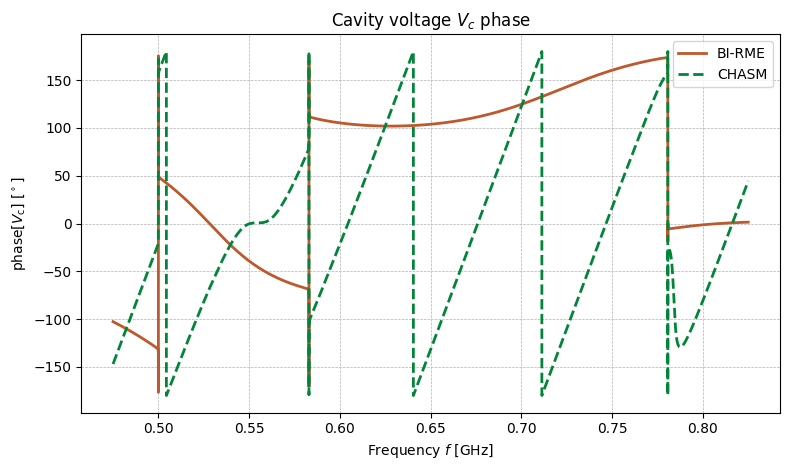

In [122]:
PHASE_SHIFT_deg = 0 # Phase shift in degrees
PHASE_SHIFT_rad = PHASE_SHIFT_deg/180*np.pi

plt.figure(figsize=(8, 4.8))

plt.plot(
    freqs_BIRME / 1e9,
    np.angle(V_c_BIRME, deg=True),
    color="#be582d",
    linewidth=2,
    label="BI-RME",
)

if PHASE_SHIFT_deg == 0:
    CHASM_label = "CHASM"
else:
    CHASM_label = rf"CHASM phase shifted by {PHASE_SHIFT_deg}$^\circ$"

plt.plot(
    freqs_CHASM / 1e9,
    -np.angle(V_c_CHASM * np.exp(1j * PHASE_SHIFT_rad), deg=True),
    color="#02853a",
    linewidth=2,
    label=CHASM_label,
    linestyle="--"
)

plt.xlabel(r"Frequency $f$ [GHz]")
plt.ylabel(r"$\mathrm{phase}[V_{\mathrm{c}}]$ [$^\circ$]")
plt.title(r"Cavity voltage $V_c$ phase")

plt.legend()
plt.grid(True, ls="--", lw=0.5)

plt.tight_layout()
plt.savefig(os.path.join(results_dir, f"cavity_voltage_phase"), dpi=300)
plt.show()

## Compare peak values and frequency resolution

In [123]:
# Find peaks
sim_peaks, _ = find_peaks(np.abs(V_c_BIRME))
meas_peaks, _ = find_peaks(np.abs(V_c_CHASM))

# Select the three highest peaks
top_sim = sim_peaks[np.argsort(np.abs(V_c_BIRME)[sim_peaks])[-3:]]
top_meas = meas_peaks[np.argsort(np.abs(V_c_CHASM)[meas_peaks])[-3:]]

# Sort by frequency
top_BIRME = top_sim[np.argsort(freqs_BIRME[top_sim])]
top_CHASM = top_meas[np.argsort(freqs_CHASM[top_meas])]

comparison = pd.DataFrame({
    "BI-RME freq (GHz)": freqs_BIRME[top_BIRME] / 1e9,
    "BI-RME |Vc|": np.abs(V_c_BIRME[top_BIRME]),
    "CHASM freq (GHz)": freqs_CHASM[top_CHASM] / 1e9,
    "CHASM |Vc|": np.abs(V_c_CHASM[top_CHASM]),
})

comparison["Frequency error (MHz)"] = (
    comparison["CHASM freq (GHz)"] -
    comparison["BI-RME freq (GHz)"]
) * 1000

comparison["Amplitude ratio"] = (
    comparison["CHASM |Vc|"] /
    comparison["BI-RME |Vc|"]
)

print("Peak Comparison:")
comparison

Peak Comparison:


,BI-RME freq (GHz),BI-RME |Vc|,CHASM freq (GHz),CHASM |Vc|,Frequency error (MHz),Amplitude ratio
0,0.499999,1.062441e-12,0.499967,1.890331e-12,-0.03105,1.779234
1,0.582958,2.495089e-13,0.500004,5.733216e-14,-82.95413,0.229780
2,0.582967,4.901139e-14,0.582960,3.237527e-13,-0.00655,6.605663


In [124]:
# Compute frequency spacings
df_sim = np.diff(freqs_BIRME)
df_chasm = np.diff(freqs_CHASM)

print("Frequency Spacing Comparison:")

print("\nBI-RME:")
print(f"  Min  Δf = {np.min(df_sim):.3f} Hz")
print(f"  Max  Δf = {np.max(df_sim):.3f} Hz")

print("\nCHASM:")
print(f"  Min  Δf = {np.min(df_chasm):.3f} Hz")
print(f"  Max  Δf = {np.max(df_chasm):.3f} Hz")

Frequency Spacing Comparison:

BI-RME:
  Min  Δf = 500.000 Hz
  Max  Δf = 500.000 Hz

CHASM:
  Min  Δf = 30.000 Hz
  Max  Δf = 500.000 Hz


## Plot gravitational wave current data

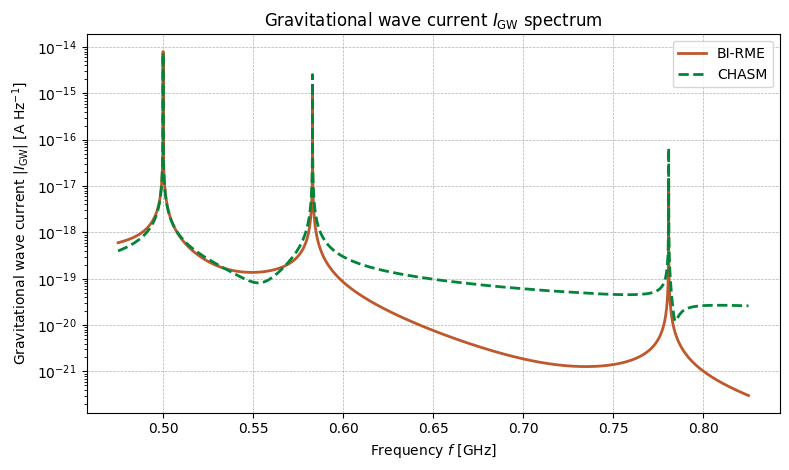

In [125]:
plt.figure(figsize=(8, 4.8))

plt.plot(
    freqs_BIRME / 1e9,
    np.abs(I_gw_BIRME),
    color="#be582d",
    linewidth=2,
    label="BI-RME",
)

plt.plot(
    freqs_CHASM / 1e9,
    np.abs(I_gw_CHASM),
    color="#02853a",
    linewidth=2,
    label="CHASM",
    linestyle="--"
)

plt.xlabel(r"Frequency $f$ [GHz]")
plt.ylabel(r"Gravitational wave current $|I_{\mathrm{GW}}|$ [A Hz$^{-1}$]")
plt.title(r"Gravitational wave current $I_{\mathrm{GW}}$ spectrum")

plt.yscale("log")
plt.legend()
plt.grid(True, ls="--", lw=0.5)

plt.tight_layout()
plt.savefig(os.path.join(results_dir, f"gw_current_spectrum"), dpi=300)
plt.show()

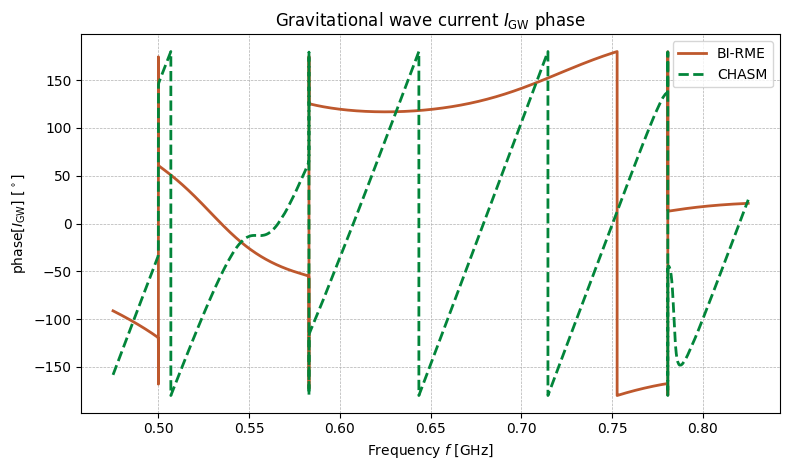

In [126]:
PHASE_SHIFT_deg = 0 # Phase shift in degrees
PHASE_SHIFT_rad = PHASE_SHIFT_deg/180*np.pi

plt.figure(figsize=(8, 4.8))

plt.plot(
    freqs_BIRME / 1e9,
    np.angle(I_gw_BIRME, deg=True),
    color="#be582d",
    linewidth=2,
    label="BI-RME",
)

if PHASE_SHIFT_deg == 0:
    CHASM_label = "CHASM"
else:
    CHASM_label = rf"CHASM phase shifted by {PHASE_SHIFT_deg}$^\circ$"

plt.plot(
    freqs_CHASM / 1e9,
    -np.angle(I_gw_CHASM * np.exp(1j * PHASE_SHIFT_rad), deg=True),
    color="#02853a",
    linewidth=2,
    label=CHASM_label,
    linestyle="--"
)

plt.xlabel(r"Frequency $f$ [GHz]")
plt.ylabel(r"$\mathrm{phase}[I_{\mathrm{GW}}]$ [$^\circ$]")
plt.title(r"Gravitational wave current $I_{\mathrm{GW}}$ phase")

plt.legend()
plt.grid(True, ls="--", lw=0.5)

plt.tight_layout()
plt.savefig(os.path.join(results_dir, f"gw_current_phase"), dpi=300)
plt.show()

## Mode by mode comparison

### Import mode by mode data

In [127]:
V_c_modes_BIRME = data_BIRME_1["V_GW_modes"].T
V_meas_modes_CHASM = data_CHASM["V_meas_modes"]

I_gw_modes_BIRME = data_BIRME_1["I_GW_modes"].T
I_gw_modes_CHASM = data_CHASM["I_gw_modes"]

#### Convert measured voltage to cavity voltage

In [128]:
a = 2.11e-3
b = 0.635e-3

V_c_modes_CHASM = V_meas_modes_CHASM / np.sqrt(np.log(a/b)/(2*np.pi))

### Plot mode by mode cavity voltage

<Figure size 800x480 with 0 Axes>

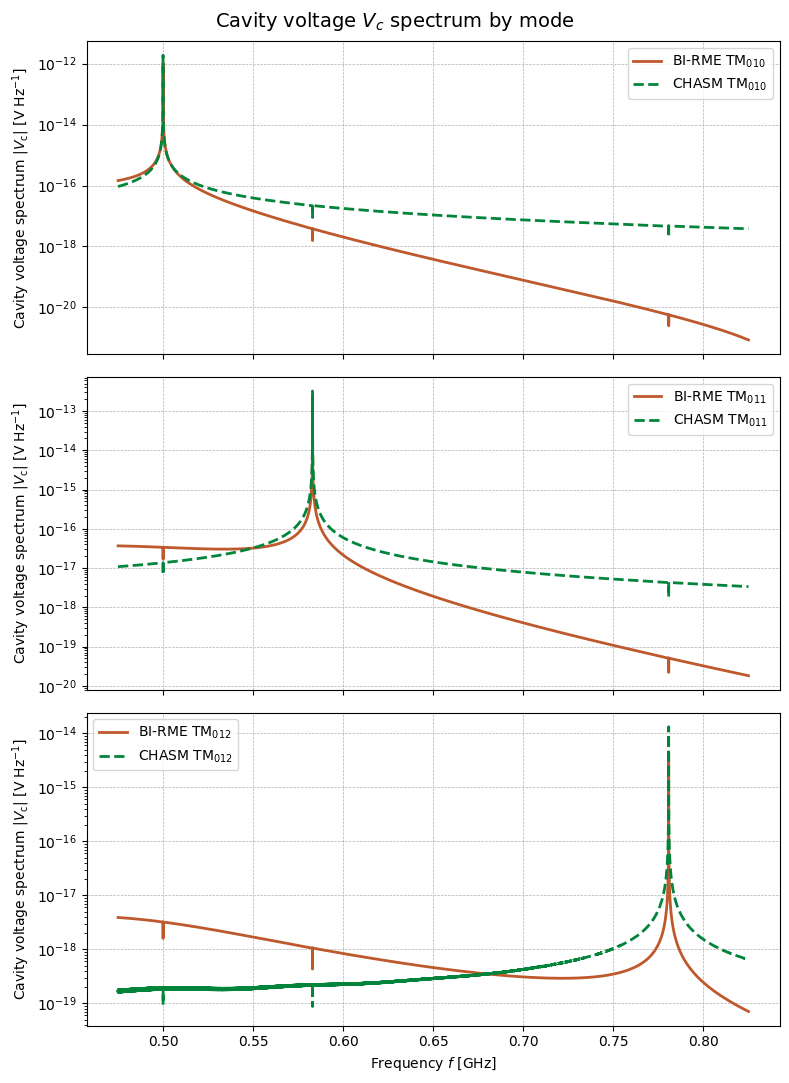

In [129]:
plt.figure(figsize=(8, 4.8))

mode_labels = [r"TM$_{010}$", r"TM$_{011}$", r"TM$_{012}$"]

fig, axes = plt.subplots(3, 1, figsize=(8, 11), sharex=True)

for ax, V_mode_BIRME, V_mode_CHASM, label in zip(axes, V_c_modes_BIRME, V_c_modes_CHASM, mode_labels):

    birme_label = f"BI-RME {label}"
    chasm_label = f"CHASM {label}"

    ax.plot(
        freqs_BIRME / 1e9,
        np.abs((V_mode_BIRME)),
        color="#be582d",
        linewidth=2,
        linestyle="-",
        label=birme_label,
    )

    ax.plot(
        freqs_CHASM / 1e9,
        np.abs((V_mode_CHASM)),
        color="#02853a",
        linewidth=2,
        linestyle="--",
        label=chasm_label,
    )
    ax.set_yscale('log')

    ax.set_ylabel(r"Cavity voltage spectrum $|V_{\mathrm{c}}|$ [V Hz$^{-1}$]")
    ax.grid(True, ls="--", lw=0.5)
    ax.legend()

axes[-1].set_xlabel(r"Frequency $f$ [GHz]")

fig.suptitle(r"Cavity voltage $V_c$ spectrum by mode", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 1])

plt.savefig(os.path.join(results_dir, f"cavity_voltage_spectrum_modes"), dpi=300)
plt.show()

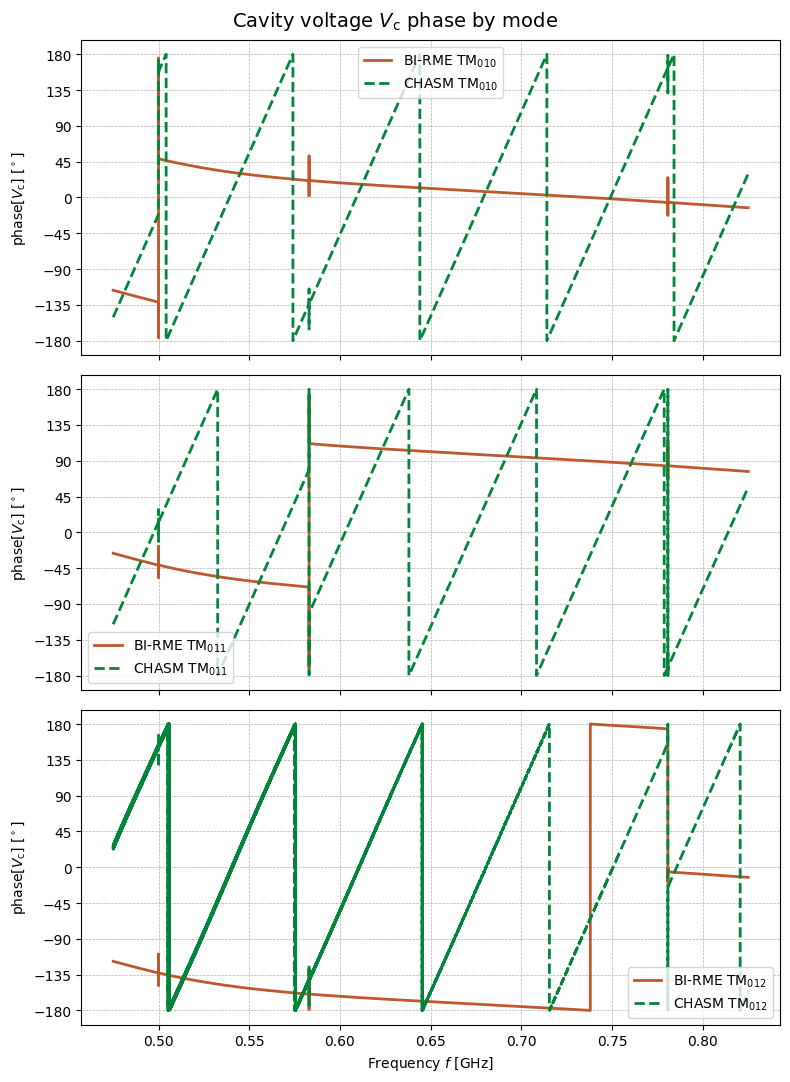

In [130]:
PHASE_SHIFT_deg = 0  # Phase shift in degrees
PHASE_SHIFT_rad = np.deg2rad(PHASE_SHIFT_deg)

fig, axes = plt.subplots(3, 1, figsize=(8, 11), sharex=True)

for ax, V_mode_BIRME, V_mode_CHASM, label in zip(axes, V_c_modes_BIRME, V_c_modes_CHASM, mode_labels):

    birme_label = f"BI-RME {label}"

    if PHASE_SHIFT_deg == 0:
        chasm_label = f"CHASM {label}"
    else:
        chasm_label = rf"CHASM {label} (+{PHASE_SHIFT_deg}$^\circ$)"

    ax.plot(
        freqs_BIRME / 1e9,
        np.angle((V_mode_BIRME), deg=True),
        color="#be582d",
        linewidth=2,
        linestyle="-",
        label=birme_label,
    )

    ax.plot(
        freqs_CHASM / 1e9,
        -np.angle((V_mode_CHASM * np.exp(1j * PHASE_SHIFT_rad)), deg=True),
        color="#02853a",
        linewidth=2,
        linestyle="--",
        label=chasm_label,
    )

    ax.set_yticks(np.arange(-180, 181, 45))
    ax.set_ylabel(r"$\mathrm{phase}[V_\mathrm{c}]$ [$^\circ$]")
    ax.grid(True, ls="--", lw=0.5)
    ax.legend()

axes[-1].set_xlabel(r"Frequency $f$ [GHz]")

fig.suptitle(r"Cavity voltage $V_\mathrm{c}$ phase by mode", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 1])
plt.savefig(os.path.join(results_dir, f"cavity_voltage_phase_modes"), dpi=300)
plt.show()

### Plot mode by mode gravitational wave current

<Figure size 800x480 with 0 Axes>

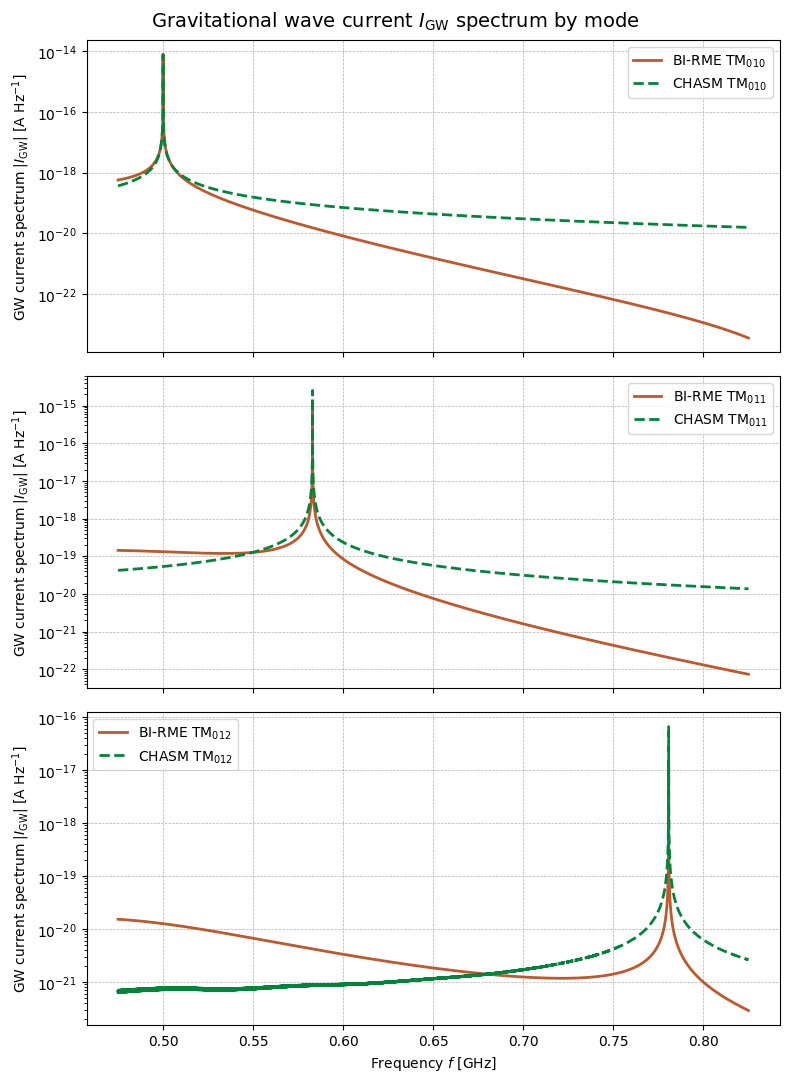

In [131]:
plt.figure(figsize=(8, 4.8))

mode_labels = [r"TM$_{010}$", r"TM$_{011}$", r"TM$_{012}$"]

fig, axes = plt.subplots(3, 1, figsize=(8, 11), sharex=True)

for ax, I_mode_BIRME, I_mode_CHASM, label in zip(axes, I_gw_modes_BIRME, I_gw_modes_CHASM, mode_labels):

    birme_label = f"BI-RME {label}"
    chasm_label = f"CHASM {label}"

    ax.plot(
        freqs_BIRME / 1e9,
        np.abs((I_mode_BIRME)),
        color="#be582d",
        linewidth=2,
        linestyle="-",
        label=birme_label,
    )

    ax.plot(
        freqs_CHASM / 1e9,
        np.abs((I_mode_CHASM)),
        color="#02853a",
        linewidth=2,
        linestyle="--",
        label=chasm_label,
    )
    ax.set_yscale('log')

    ax.set_ylabel(r"GW current spectrum $|I_\mathrm{GW}|$ [A Hz$^{-1}$]")
    ax.grid(True, ls="--", lw=0.5)
    ax.legend()

axes[-1].set_xlabel(r"Frequency $f$ [GHz]")

fig.suptitle(r"Gravitational wave current $I_\mathrm{GW}$ spectrum by mode", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 1])
plt.savefig(os.path.join(results_dir, f"gw_current_spectrum_modes"), dpi=300)
plt.show()

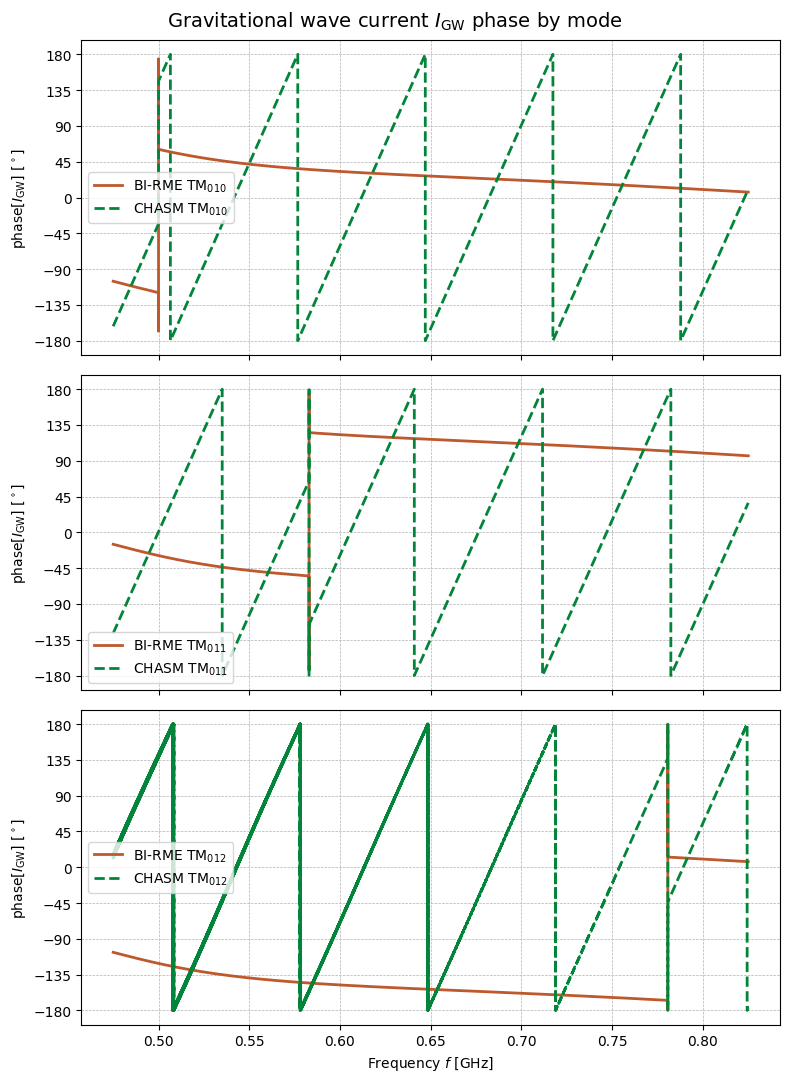

In [132]:
PHASE_SHIFT_deg = 0  # Phase shift in degrees
PHASE_SHIFT_rad = np.deg2rad(PHASE_SHIFT_deg)

fig, axes = plt.subplots(3, 1, figsize=(8, 11), sharex=True)

for ax, I_mode_BIRME, I_mode_CHASM, label in zip(axes, I_gw_modes_BIRME, I_gw_modes_CHASM, mode_labels):

    birme_label = f"BI-RME {label}"

    if PHASE_SHIFT_deg == 0:
        chasm_label = f"CHASM {label}"
    else:
        chasm_label = rf"CHASM {label} (+{PHASE_SHIFT_deg}$^\circ$)"

    ax.plot(
        freqs_BIRME / 1e9,
        np.angle((I_mode_BIRME), deg=True),
        color="#be582d",
        linewidth=2,
        linestyle="-",
        label=birme_label,
    )

    ax.plot(
        freqs_CHASM / 1e9,
        -np.angle((I_mode_CHASM * np.exp(1j * PHASE_SHIFT_rad)), deg=True),
        color="#02853a",
        linewidth=2,
        linestyle="--",
        label=chasm_label,
    )

    ax.set_yticks(np.arange(-180, 181, 45))
    ax.set_ylabel(r"$\mathrm{phase}[I_\mathrm{GW}]$ [$^\circ$]")
    ax.grid(True, ls="--", lw=0.5)
    ax.legend()

axes[-1].set_xlabel(r"Frequency $f$ [GHz]")

fig.suptitle(r"Gravitational wave current $I_\mathrm{GW}$ phase by mode", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 1])
plt.savefig(os.path.join(results_dir, f"gw_current_phase_modes"), dpi=300)
plt.show()

## Estimate the optimal frequency shift between CHASM and BI-RME

In [ ]:
def find_phase_shift(X_birme, X_chasm, freqs_birme=freqs_BIRME, freqs_chasm=freqs_CHASM, negate_chasm=True, resolution=0.5):

    # Flatten everything
    freqs_birme = np.asarray(freqs_birme).ravel()
    X_birme = np.asarray(X_birme).ravel()
    freqs_chasm = np.asarray(freqs_chasm).ravel()
    X_chasm = np.asarray(X_chasm).ravel()

    # Interpolate the complex CHASM signal
    X_chasm = (
        np.interp(freqs_birme, freqs_chasm, X_chasm.real)
        + 1j * np.interp(freqs_birme, freqs_chasm, X_chasm.imag)
    )

    phase_birme = np.angle(X_birme, deg=True)

    shifts = np.arange(-180, 180 + resolution, resolution)
    errors = np.empty(len(shifts))

    for i, shift in enumerate(shifts):

        phase_chasm = np.angle(
            X_chasm * np.exp(1j * np.deg2rad(shift)),
            deg=True,
        )

        if negate_chasm:
            phase_chasm = -phase_chasm

        diff = ((phase_birme - phase_chasm + 180) % 360) - 180
        errors[i] = np.sqrt(np.mean(diff**2))

    idx = np.argmin(errors)

    return shifts[idx]

In [30]:
phase_shift = find_phase_shift(V_c_BIRME, V_c_CHASM)
print(f"Best phase shift for V_c: {phase_shift}°")

Best phase shift for V_c: -2.5°


In [31]:
phase_shift = find_phase_shift(I_gw_BIRME, I_gw_CHASM)
print(f"Best phase shift for I_gw: {phase_shift}°")

Best phase shift for I_gw: -32.5°


In [32]:
mode_labels = [r"TM$_{010}$", r"TM$_{011}$", r"TM$_{012}$"]

for i, label in enumerate(mode_labels):
    shift = find_phase_shift(
        V_c_modes_BIRME[i],
        V_c_modes_CHASM[i],
    )

    print(f"Best phase shift for V_c in mode {label} = {shift}°")

Best phase shift for V_c in mode TM$_{010}$ = -163.5°
Best phase shift for V_c in mode TM$_{011}$ = -72.0°
Best phase shift for V_c in mode TM$_{012}$ = 50.5°


In [33]:
mode_labels = [r"TM$_{010}$", r"TM$_{011}$", r"TM$_{012}$"]

for i, label in enumerate(mode_labels):
    shift = find_phase_shift(
        I_gw_modes_BIRME[i],
        I_gw_modes_CHASM[i],
    )

    print(f"Best phase shift for I_gw in mode {label} = {shift}°")

Best phase shift for I_gw in mode TM$_{010}$ = 159.0°
Best phase shift for I_gw in mode TM$_{011}$ = -109.5°
Best phase shift for I_gw in mode TM$_{012}$ = 13.0°
